<a href="https://colab.research.google.com/github/felipetavaressilvaoliveira-netizen/senacai/blob/main/analise_risco_credito_Terca_feira.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd

# Carregar o arquivo credit_risk_dataset.xlsx
df_credit_risk = pd.read_excel('/content/credit_risk_dataset.xlsx')

In [3]:
# Exibir os nomes das colunas
print("Colunas do DataFrame:")
display(df_credit_risk.columns)

# Exibir as primeiras 5 linhas do DataFrame
print("\nPrimeiras 5 linhas do DataFrame:")
display(df_credit_risk.head())

Colunas do DataFrame:


Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_status', 'loan_percent_income',
       'cb_person_default_on_file', 'cb_person_cred_hist_length'],
      dtype='object')


Primeiras 5 linhas do DataFrame:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [4]:
# Contar valores nulos por coluna
null_counts = df_credit_risk.isnull().sum()

# Filtrar colunas que possuem valores nulos
columns_with_nulls = null_counts[null_counts > 0]

# Exibir as colunas com a quantidade de valores nulos
if not columns_with_nulls.empty:
    print("Colunas com valores nulos e suas respectivas contagens:")
    display(columns_with_nulls)
else:
    print("Não há colunas com valores nulos no dataset.")

Colunas com valores nulos e suas respectivas contagens:


,0
person_emp_length,895
loan_int_rate,3116


### 1. Tratamento de Valores Ausentes

Vamos preencher os valores nulos das colunas `person_emp_length` e `loan_int_rate` com a **mediana** de cada coluna, que é uma abordagem robusta para dados numéricos quando há outliers ou distribuições não normais.

In [5]:
# Preencher valores nulos em 'person_emp_length' com a mediana
median_emp_length = df_credit_risk['person_emp_length'].median()
df_credit_risk['person_emp_length'].fillna(median_emp_length, inplace=True)

# Preencher valores nulos em 'loan_int_rate' com a mediana
median_int_rate = df_credit_risk['loan_int_rate'].median()
df_credit_risk['loan_int_rate'].fillna(median_int_rate, inplace=True)

print("Valores nulos após o preenchimento:")
display(df_credit_risk.isnull().sum())

Valores nulos após o preenchimento:


/tmp/ipykernel_6472/4227448694.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_credit_risk['person_emp_length'].fillna(median_emp_length, inplace=True)
/tmp/ipykernel_6472/4227448694.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(

,0
person_age,0
person_income,0
person_home_ownership,0
person_emp_length,0
loan_intent,0
loan_grade,0
loan_amnt,0
loan_int_rate,0
loan_status,0
loan_percent_income,0


### 2. Codificação de Variáveis Categóricas

Vamos identificar as colunas categóricas e aplicar o One-Hot Encoding para convertê-las em um formato numérico. Isso é essencial para que os algoritmos de Machine Learning possam processá-las.

In [6]:
# Identificar colunas categóricas
categorical_cols = df_credit_risk.select_dtypes(include=['object', 'bool']).columns

# Aplicar One-Hot Encoding
df_credit_risk_encoded = pd.get_dummies(df_credit_risk, columns=categorical_cols, drop_first=True)

print("Colunas após One-Hot Encoding:")
display(df_credit_risk_encoded.head())

Colunas após One-Hot Encoding:


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,1,0.59,3,False,False,...,False,True,False,False,False,True,False,False,False,True
1,21,9600,5.0,1000,11.14,0,0.10,2,False,True,...,False,False,False,True,False,False,False,False,False,False
2,25,9600,1.0,5500,12.87,1,0.57,3,False,False,...,True,False,False,False,True,False,False,False,False,False
3,23,65500,4.0,35000,15.23,1,0.53,2,False,False,...,True,False,False,False,True,False,False,False,False,False
4,24,54400,8.0,35000,14.27,1,0.55,4,False,False,...,True,False,False,False,True,False,False,False,False,True


### 3. Divisão dos Dados

Agora vamos separar os dados em variáveis preditoras (X) e variável alvo (y). A variável alvo será `loan_status` (indicando inadimplência ou não). Em seguida, dividiremos esses dados em conjuntos de treino e teste para avaliar o desempenho do modelo em dados não vistos.

In [7]:
from sklearn.model_selection import train_test_split

# Separar features (X) e variável alvo (y)
X = df_credit_risk_encoded.drop('loan_status', axis=1)
y = df_credit_risk_encoded['loan_status']

# Dividir os dados em conjuntos de treino e teste (80% treino, 20% teste)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train): {X_train.shape}")
print(f"Tamanho do conjunto de teste (X_test): {X_test.shape}")
print(f"Distribuição da variável alvo no treino:\n{y_train.value_counts(normalize=True)}")
print(f"Distribuição da variável alvo no teste:\n{y_test.value_counts(normalize=True)}")

Tamanho do conjunto de treino (X_train): (26064, 22)
Tamanho do conjunto de teste (X_test): (6517, 22)
Distribuição da variável alvo no treino:
loan_status
0    0.781845
1    0.218155
Name: proportion, dtype: float64
Distribuição da variável alvo no teste:
loan_status
0    0.781801
1    0.218199
Name: proportion, dtype: float64


### 4. Treinamento e Avaliação do Modelo

Vamos treinar um modelo de Regressão Logística e, em seguida, avaliar seu desempenho usando a Matriz de Confusão e a Curva ROC.

Matriz de Confusão:


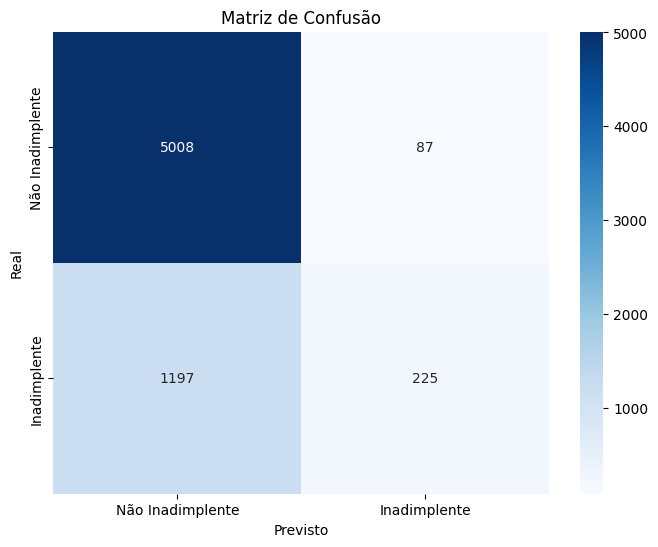


Área sob a Curva ROC (AUC): 0.7605


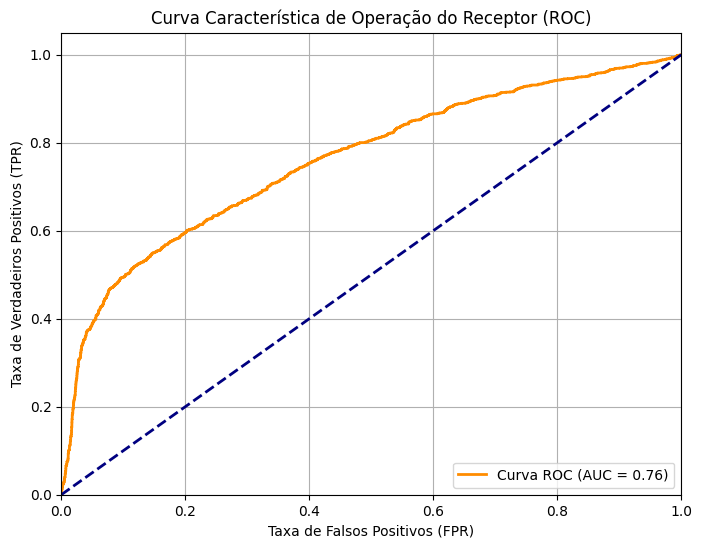

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar e treinar o modelo de Regressão Logística
model = LogisticRegression(solver='liblinear', random_state=42)
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# 1. Matriz de Confusão
conf_matrix = confusion_matrix(y_test, y_pred)
print("Matriz de Confusão:")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Inadimplente', 'Inadimplente'],
            yticklabels=['Não Inadimplente', 'Inadimplente'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão')
plt.show()

# 2. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"\nÁrea sob a Curva ROC (AUC): {roc_auc:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva Característica de Operação do Receptor (ROC)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

### 5. Balanceamento dos Dados com SMOTE

Como identificamos que o dataset está desbalanceado (a classe de inadimplentes é minoritária), vamos aplicar a técnica SMOTE para superamostrar a classe minoritária no conjunto de treino. Isso ajudará o modelo a aprender melhor sobre os casos de inadimplência.

In [9]:
from imblearn.over_sampling import SMOTE

# Inicializar SMOTE
smote = SMOTE(random_state=42)

# Aplicar SMOTE apenas no conjunto de treino
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("Distribuição da variável alvo no treino após SMOTE:\n")
display(y_train_resampled.value_counts(normalize=True))

Distribuição da variável alvo no treino após SMOTE:



,proportion
loan_status,
0,0.5
1,0.5


### 6. Retreinar e Reavaliar o Modelo com Dados Balanceados

Com os dados de treino balanceados pelo SMOTE, vamos treinar novamente o modelo de Regressão Logística e analisar seu desempenho. É importante avaliar o modelo no conjunto de teste original para ter uma ideia realista de sua performance em dados não vistos.

Matriz de Confusão (após SMOTE):


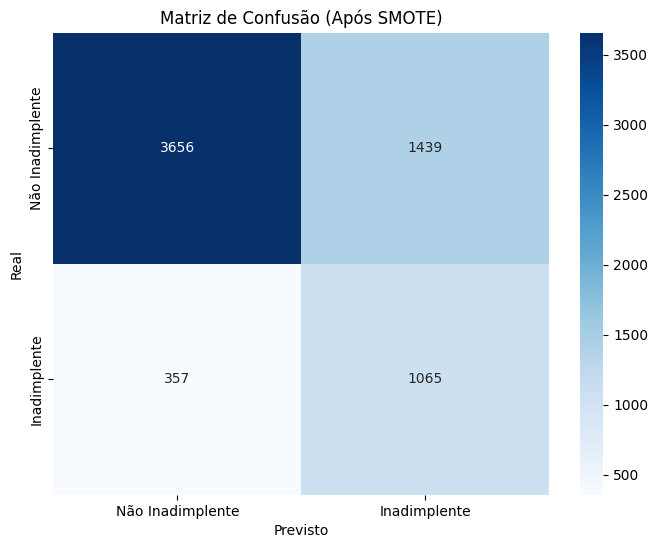


Área sob a Curva ROC (AUC) (após SMOTE): 0.8126


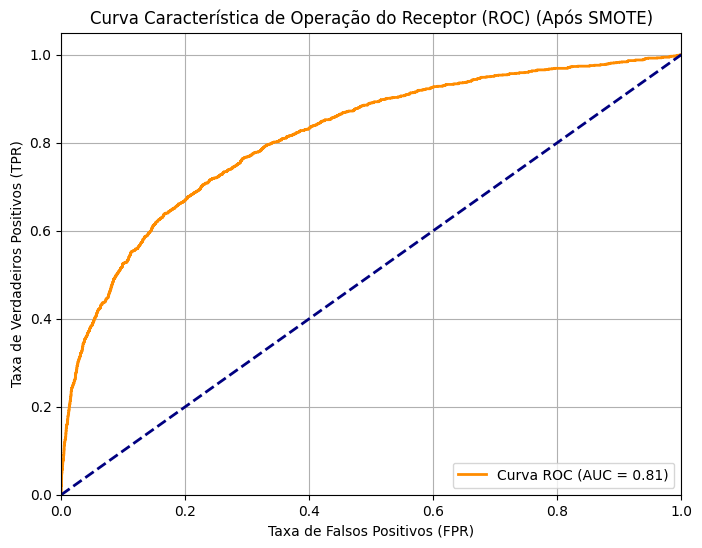


Relatório de Classificação (após SMOTE):
              precision    recall  f1-score   support

           0       0.91      0.72      0.80      5095
           1       0.43      0.75      0.54      1422

    accuracy                           0.72      6517
   macro avg       0.67      0.73      0.67      6517
weighted avg       0.81      0.72      0.75      6517



In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Inicializar e treinar o modelo de Regressão Logística com dados balanceados
model_resampled = LogisticRegression(solver='liblinear', random_state=42)
model_resampled.fit(X_train_resampled, y_train_resampled)

# Fazer previsões no conjunto de teste ORIGINAL
y_pred_resampled = model_resampled.predict(X_test)
y_pred_proba_resampled = model_resampled.predict_proba(X_test)[:, 1]

# 1. Matriz de Confusão com dados balanceados
conf_matrix_resampled = confusion_matrix(y_test, y_pred_resampled)
print("Matriz de Confusão (após SMOTE):")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_resampled, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Inadimplente', 'Inadimplente'],
            yticklabels=['Não Inadimplente', 'Inadimplente'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Após SMOTE)')
plt.show()

# 2. Curva ROC com dados balanceados
fpr_resampled, tpr_resampled, thresholds_resampled = roc_curve(y_test, y_pred_proba_resampled)
roc_auc_resampled = roc_auc_score(y_test, y_pred_proba_resampled)

print(f"\nÁrea sob a Curva ROC (AUC) (após SMOTE): {roc_auc_resampled:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr_resampled, tpr_resampled, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_resampled:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva Característica de Operação do Receptor (ROC) (Após SMOTE)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Opcional: Relatório de Classificação para mais métricas
print("\nRelatório de Classificação (após SMOTE):")
print(classification_report(y_test, y_pred_resampled))

### 7. Análise da Importância das Variáveis (Coeficientes do Modelo)

Para avaliar a contribuição de cada variável para a previsão do modelo de Regressão Logística, podemos analisar os coeficientes atribuídos. Coeficientes com valores absolutos maiores indicam uma maior influência daquela feature na decisão do modelo.

In [11]:
import pandas as pd

# Obter os nomes das features do conjunto de treino (após o SMOTE)
feature_names = X_train_resampled.columns

# Obter os coeficientes do modelo treinado (após o SMOTE)
coefficients = model_resampled.coef_[0]

# Criar um DataFrame para exibir os coeficientes
feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

# Ordenar as features pelo valor absoluto do coeficiente
feature_importance['Absolute_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values(by='Absolute_Coefficient', ascending=False)

print("Peso de cada variável na análise do modelo (Coeficientes do Modelo):")
display(feature_importance.drop(columns='Absolute_Coefficient'))

Peso de cada variável na análise do modelo (Coeficientes do Modelo):


,Feature,Coefficient
4,loan_int_rate,0.238822
17,loan_grade_D,0.196021
9,person_home_ownership_RENT,0.176951
21,cb_person_default_on_file_Y,0.134838
0,person_age,-0.092410
12,loan_intent_MEDICAL,0.092163
11,loan_intent_HOMEIMPROVEMENT,0.079325
6,cb_person_cred_hist_length,0.075616
18,loan_grade_E,0.063044
8,person_home_ownership_OWN,-0.046444


### 8. Remoção de Variáveis de Baixa Importância e Retreinamento do Modelo

Com base na análise dos coeficientes, as variáveis `loan_amnt` e `person_income` apresentaram coeficientes muito próximos de zero, indicando pouca influência na predição do modelo. Vamos removê-las do conjunto de features, refazer o processo de divisão de dados e balanceamento (SMOTE), e então retreinar e reavaliar o modelo para verificar o impacto dessa simplificação.

Novas colunas de features: ['person_age', 'person_emp_length', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'loan_grade_B', 'loan_grade_C', 'loan_grade_D', 'loan_grade_E', 'loan_grade_F', 'loan_grade_G', 'cb_person_default_on_file_Y']

Tamanho do conjunto de treino (X_train_reduced): (26064, 20)
Tamanho do conjunto de teste (X_test_reduced): (6517, 20)

Distribuição da variável alvo no treino após SMOTE (features reduzidas):



,proportion
loan_status,
0,0.5
1,0.5



Matriz de Confusão (Após SMOTE e remoção de features):


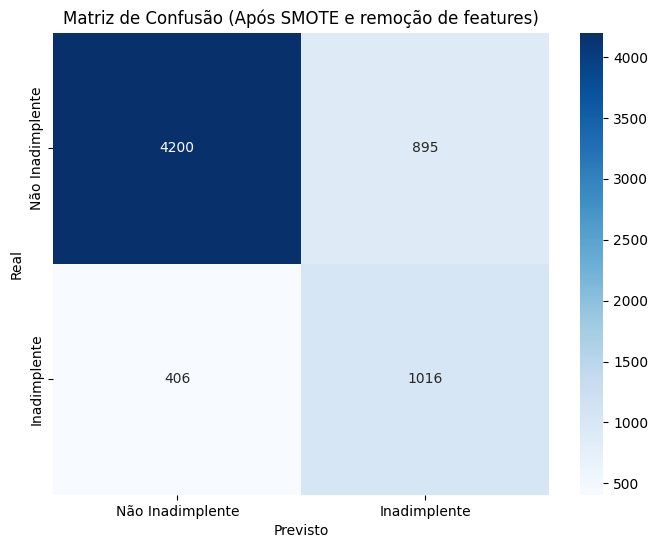


Área sob a Curva ROC (AUC) (Após SMOTE e remoção de features): 0.8341


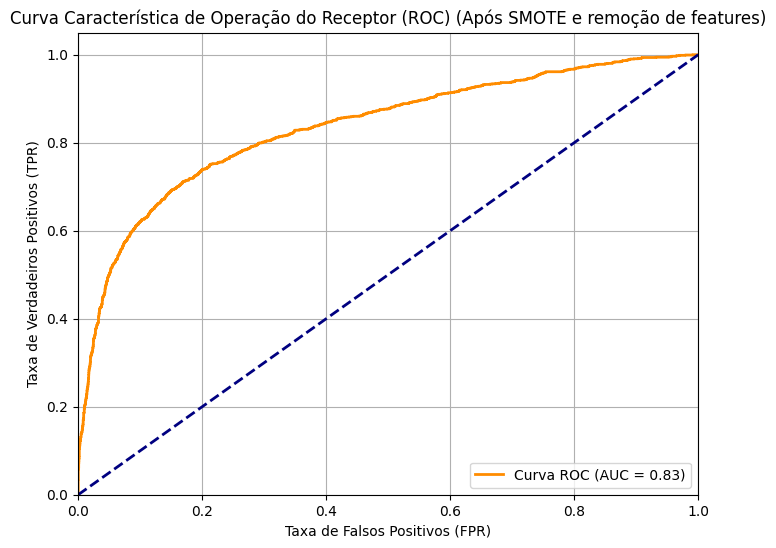


Relatório de Classificação (Após SMOTE e remoção de features):
              precision    recall  f1-score   support

           0       0.91      0.82      0.87      5095
           1       0.53      0.71      0.61      1422

    accuracy                           0.80      6517
   macro avg       0.72      0.77      0.74      6517
weighted avg       0.83      0.80      0.81      6517



In [12]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Variáveis a serem removidas
low_importance_features = ['loan_amnt', 'person_income']

# Criar um novo conjunto de features (X_reduced) sem as variáveis de baixa importância
X_reduced = df_credit_risk_encoded.drop(columns=low_importance_features + ['loan_status'], axis=1)
y = df_credit_risk_encoded['loan_status']

print(f"Novas colunas de features: {X_reduced.columns.tolist()}\n")

# 1. Re-dividir os dados em conjuntos de treino e teste com o X_reduced
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(X_reduced, y, test_size=0.2, random_state=42, stratify=y)

print(f"Tamanho do conjunto de treino (X_train_reduced): {X_train_reduced.shape}")
print(f"Tamanho do conjunto de teste (X_test_reduced): {X_test_reduced.shape}")

# 2. Re-aplicar SMOTE no conjunto de treino reduzido
smote_reduced = SMOTE(random_state=42)
X_train_resampled_reduced, y_train_resampled_reduced = smote_reduced.fit_resample(X_train_reduced, y_train_reduced)

print("\nDistribuição da variável alvo no treino após SMOTE (features reduzidas):\n")
display(y_train_resampled_reduced.value_counts(normalize=True))

# 3. Re-treinar o modelo de Regressão Logística com dados balanceados e reduzidos
model_reduced = LogisticRegression(solver='liblinear', random_state=42)
model_reduced.fit(X_train_resampled_reduced, y_train_resampled_reduced)

# Fazer previsões no conjunto de teste ORIGINAL (reduzido também)
y_pred_reduced = model_reduced.predict(X_test_reduced)
y_pred_proba_reduced = model_reduced.predict_proba(X_test_reduced)[:, 1]

# 4. Matriz de Confusão com dados reduzidos
conf_matrix_reduced = confusion_matrix(y_test_reduced, y_pred_reduced)
print("\nMatriz de Confusão (Após SMOTE e remoção de features):")
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_reduced, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Não Inadimplente', 'Inadimplente'],
            yticklabels=['Não Inadimplente', 'Inadimplente'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão (Após SMOTE e remoção de features)')
plt.show()

# 5. Curva ROC com dados reduzidos
fpr_reduced, tpr_reduced, thresholds_reduced = roc_curve(y_test_reduced, y_pred_proba_reduced)
roc_auc_reduced = roc_auc_score(y_test_reduced, y_pred_proba_reduced)

print(f"\nÁrea sob a Curva ROC (AUC) (Após SMOTE e remoção de features): {roc_auc_reduced:.4f}")

plt.figure(figsize=(8, 6))
plt.plot(fpr_reduced, tpr_reduced, color='darkorange', lw=2, label=f'Curva ROC (AUC = {roc_auc_reduced:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taxa de Falsos Positivos (FPR)')
plt.ylabel('Taxa de Verdadeiros Positivos (TPR)')
plt.title('Curva Característica de Operação do Receptor (ROC) (Após SMOTE e remoção de features)')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()

# Relatório de Classificação para mais métricas
print("\nRelatório de Classificação (Após SMOTE e remoção de features):")
print(classification_report(y_test_reduced, y_pred_reduced))

### 9. Validação do Modelo com Novo Dataset

Agora, vamos carregar o dataset de validação (`credit_risk_validation.xlsx`) e aplicar os mesmos passos de pré-processamento que foram usados no dataset de treino. Isso inclui o preenchimento de nulos, One-Hot Encoding e a remoção das variáveis de baixa importância. Em seguida, usaremos o `model_reduced` para prever o risco de crédito para esses novos clientes.

In [13]:
# Carregar o dataset de validação
df_validation = pd.read_excel('/content/credit_risk_validation.xlsx')

print("Primeiras 5 linhas do dataset de validação:")
display(df_validation.head())

print("\nValores nulos no dataset de validação (antes do tratamento):")
display(df_validation.isnull().sum()[df_validation.isnull().sum() > 0])

Primeiras 5 linhas do dataset de validação:


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,27,64928,MORTGAGE,6.895519,MEDICAL,B,26253,8.666467,0.404340,N,3
1,28,30308,OWN,5.043709,VENTURE,B,2406,7.835118,0.079385,Y,10
2,28,125995,MORTGAGE,1.767264,DEBTCONSOLIDATION,A,23926,5.728312,0.189896,N,2
3,27,78701,MORTGAGE,4.835299,HOMEIMPROVEMENT,B,8271,9.981185,0.105094,N,2
4,38,146253,MORTGAGE,2.606058,MEDICAL,B,13562,7.624272,0.092730,N,7



Valores nulos no dataset de validação (antes do tratamento):


,0
person_emp_length,83


In [14]:
# Preencher valores nulos em 'person_emp_length' e 'loan_int_rate' com as medianas do TREINO original
df_validation['person_emp_length'].fillna(median_emp_length, inplace=True)
df_validation['loan_int_rate'].fillna(median_int_rate, inplace=True)

print("Valores nulos no dataset de validação (após preenchimento com medianas do treino):")
display(df_validation.isnull().sum()[df_validation.isnull().sum() > 0])

Valores nulos no dataset de validação (após preenchimento com medianas do treino):


/tmp/ipykernel_6472/3111378258.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_validation['person_emp_length'].fillna(median_emp_length, inplace=True)
/tmp/ipykernel_6472/3111378258.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,0


In [15]:
# Identificar colunas categóricas no dataset de validação
categorical_cols_validation = df_validation.select_dtypes(include=['object', 'bool']).columns

# Aplicar One-Hot Encoding no dataset de validação
df_validation_encoded = pd.get_dummies(df_validation, columns=categorical_cols_validation, drop_first=True)

# Remover 'loan_status' se existir no dataset de validação (pois é a variável que queremos prever)
if 'loan_status' in df_validation_encoded.columns:
    df_validation_encoded = df_validation_encoded.drop('loan_status', axis=1)

# Remover as variáveis de baixa importância identificadas anteriormente
low_importance_features = ['loan_amnt', 'person_income']
df_validation_encoded = df_validation_encoded.drop(columns=low_importance_features, errors='ignore')

# Garantir que as colunas do df_validation_encoded correspondam às colunas do X_train_resampled_reduced
# Isso é crucial para evitar erros no predict

# Obter as colunas do conjunto de treino reduzido
train_cols = X_train_resampled_reduced.columns

# Adicionar colunas ausentes no df_validation_encoded com valor 0
missing_cols = set(train_cols) - set(df_validation_encoded.columns)
for c in missing_cols:
    df_validation_encoded[c] = 0

# Remover colunas que estão no df_validation_encoded mas não no conjunto de treino
extra_cols = set(df_validation_encoded.columns) - set(train_cols)
df_validation_encoded = df_validation_encoded.drop(columns=list(extra_cols), errors='ignore')

# Reordenar as colunas do df_validation_encoded para que correspondam à ordem das colunas do treino
df_validation_processed = df_validation_encoded[train_cols]

print("\nPrimeiras 5 linhas do dataset de validação processado:")
display(df_validation_processed.head())

print("\nColunas do dataset de validação processado (devem ser as mesmas do treino):")
display(df_validation_processed.columns.tolist())

print("\nQuantidade de colunas do dataset de validação processado:", df_validation_processed.shape[1])
print("Quantidade de colunas do dataset de treino reduzido:", X_train_resampled_reduced.shape[1])


Primeiras 5 linhas do dataset de validação processado:


,person_age,person_emp_length,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_OTHER,person_home_ownership_OWN,person_home_ownership_RENT,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_Y
0,27,6.895519,8.666467,0.404340,3,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False
1,28,5.043709,7.835118,0.079385,10,False,True,False,False,False,False,False,True,True,False,False,False,False,False,True
2,28,1.767264,5.728312,0.189896,2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,27,4.835299,9.981185,0.105094,2,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False
4,38,2.606058,7.624272,0.092730,7,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False



Colunas do dataset de validação processado (devem ser as mesmas do treino):


['person_age',
 'person_emp_length',
 'loan_int_rate',
 'loan_percent_income',
 'cb_person_cred_hist_length',
 'person_home_ownership_OTHER',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_HOMEIMPROVEMENT',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'loan_grade_B',
 'loan_grade_C',
 'loan_grade_D',
 'loan_grade_E',
 'loan_grade_F',
 'loan_grade_G',
 'cb_person_default_on_file_Y']


Quantidade de colunas do dataset de validação processado: 20
Quantidade de colunas do dataset de treino reduzido: 20


In [16]:
# Fazer as previsões de risco de crédito com o modelo treinado (model_reduced)
# O modelo retornará 0 para 'Não Inadimplente' e 1 para 'Inadimplente'
predictions = model_reduced.predict(df_validation_processed)

# Adicionar as previsões ao DataFrame original de validação para visualização
df_validation['predicted_loan_status'] = predictions

print("\nDataset de validação com as previsões de risco de crédito:")
display(df_validation[['person_age', 'person_income', 'loan_int_rate', 'predicted_loan_status']].head(10))

print("\nContagem de previsões (0 = Não Inadimplente, 1 = Inadimplente):")
display(df_validation['predicted_loan_status'].value_counts())


Dataset de validação com as previsões de risco de crédito:


,person_age,person_income,loan_int_rate,predicted_loan_status
0,27,64928,8.666467,1
1,28,30308,7.835118,0
2,28,125995,5.728312,0
3,27,78701,9.981185,0
4,38,146253,7.624272,0
5,32,33141,15.911382,1
6,24,78355,9.943446,0
7,26,76766,7.892167,0
8,30,21126,5.890741,0
9,25,63606,6.782987,0



Contagem de previsões (0 = Não Inadimplente, 1 = Inadimplente):


,count
predicted_loan_status,
0,3826
1,1174


In [25]:
import pandas as pd

# Certifique-se de que as medianas e as colunas de treino estão acessíveis
# median_emp_length e median_int_rate foram definidas anteriormente
# X_train_resampled_reduced.columns (train_cols) foi usado para alinhamento

def predict_risk_from_file(file_path):
    """
    Carrega um arquivo Excel do ambiente do Colab, aplica o pré-processamento
    e faz previsões de risco de crédito usando o modelo treinado.

    Args:
        file_path (str): O caminho completo do arquivo Excel no ambiente do Colab.

    Returns:
        pandas.DataFrame: O DataFrame original com colunas 'Nome_Cliente', 'predicted_loan_status' (0=baixo risco, 1=alto risco)
                          e 'predicted_risk_percentage' (probabilidade de alto risco em %).
    """
    try:
        # Carregar o dataset
        df_new_data = pd.read_excel(file_path)
        print(f"Dataset '{file_path.split('/')[-1]}' carregado com sucesso. Linhas: {df_new_data.shape[0]}, Colunas: {df_new_data.shape[1]}")
        print(f"Colunas originais no arquivo '{file_path.split('/')[-1]}': {df_new_data.columns.tolist()}\n")

        # Manter uma cópia para adicionar as previsões ao final
        df_original_for_output = df_new_data.copy()

        # Extrair a coluna 'nome' (Nome do Cliente) antes de qualquer pré-processamento de features
        client_name_col_in_file = 'nome'
        if client_name_col_in_file in df_new_data.columns:
            client_names = df_new_data[client_name_col_in_file]
            df_new_data = df_new_data.drop(columns=[client_name_col_in_file])
            print(f"Coluna '{client_name_col_in_file}' extraída com sucesso para usar como 'Nome_Cliente'.")
        else:
            client_names = pd.Series([f'Cliente_{i+1}' for i in range(len(df_new_data))])
            print(f"Coluna '{client_name_col_in_file}' não encontrada no arquivo. Gerando nomes de cliente padrão.")

        # Mapeamento de nomes de colunas do português (do arquivo) para o inglês (esperado pelo modelo)
        column_name_mapping = {
            'idade_da_pessoa': 'person_age',
            'renda_da_pessoa': 'person_income',
            'propriedade_da_pessoa': 'person_home_ownership',
            'tempo_de_emprego_da_pessoa': 'person_emp_length', # CORRIGIDO
            'intenção_de_emprestimo': 'loan_intent',
            'Classificação_de_credito': 'loan_grade',
            'valor_do_emprestimo': 'loan_amnt',
            'taxa_de_juros_do_emprestimo': 'loan_int_rate',
            'percentual_de_renda_do_emprestimo': 'loan_percent_income',
            'inadimplência_da_pessoa_registrada_no_arquivo': 'cb_person_default_on_file',
            'histórico_de_credenciamento_da_pessoa_no_arquivo': 'cb_person_cred_hist_length'
        }

        # Renomear colunas do DataFrame de entrada, apenas as que existem no df_new_data
        actual_columns_after_client_name_removal = df_new_data.columns.tolist()
        filtered_column_name_mapping = {k: v for k, v in column_name_mapping.items() if k in actual_columns_after_client_name_removal}
        df_new_data = df_new_data.rename(columns=filtered_column_name_mapping)
        print("Colunas renomeadas para o formato esperado pelo modelo (apenas as presentes no arquivo).\n")
        print(f"Colunas após renomeação: {df_new_data.columns.tolist()}\n")

        # VERIFICAÇÃO CRÍTICA: As colunas necessárias para o preenchimento de nulos existem?
        required_fill_cols = ['person_emp_length', 'loan_int_rate']
        reverse_mapping = {v: k for k, v in column_name_mapping.items()} # Mapeamento inverso para a mensagem de erro
        for col in required_fill_cols:
            if col not in df_new_data.columns:
                original_portuguese_name = reverse_mapping.get(col, f"o equivalente em português para '{col}'")
                raise ValueError(
                    f"Erro: A coluna essencial '{col}' (esperada após renomeação de '{original_portuguese_name}') não foi encontrada no dataset.\n"
                    f"Por favor, verifique se o arquivo de entrada '{file_path.split('/')[-1]}' contém uma coluna com o nome em português correspondente e se o mapeamento está correto."
                )

        # 1. Tratamento de valores nulos (usando medianas do treino original)
        df_new_data['person_emp_length'].fillna(median_emp_length, inplace=True)
        df_new_data['loan_int_rate'].fillna(median_int_rate, inplace=True)
        print("Valores nulos preenchidos com as medianas do conjunto de treino.")

        # 2. Codificação de Variáveis Categóricas (One-Hot Encoding)
        categorical_cols_new_data = df_new_data.select_dtypes(include=['object', 'bool']).columns
        df_new_data_encoded = pd.get_dummies(df_new_data, columns=categorical_cols_new_data, drop_first=True)
        print("One-Hot Encoding aplicado.")

        # 3. Remover variáveis de baixa importância
        low_importance_features = ['loan_amnt', 'person_income'] # Definidas anteriormente
        df_new_data_encoded = df_new_data_encoded.drop(columns=low_importance_features, errors='ignore')
        print(f"Variáveis de baixa importância {low_importance_features} removidas (se presentes).\n")

        # 4. Alinhar colunas com as colunas do dataset de treino reduzido
        train_cols = X_train_resampled_reduced.columns # Colunas usadas no treino do model_reduced

        # Adicionar colunas ausentes no df_new_data_encoded com valor 0
        missing_cols = set(train_cols) - set(df_new_data_encoded.columns)
        for c in missing_cols:
            df_new_data_encoded[c] = 0

        # Remover colunas que estão no df_new_data_encoded mas não no conjunto de treino
        extra_cols = set(df_new_data_encoded.columns) - set(train_cols)
        df_new_data_encoded = df_new_data_encoded.drop(columns=list(extra_cols), errors='ignore')

        # Reordenar as colunas do df_new_data_encoded para que correspondam à ordem das colunas do treino
        df_processed_for_prediction = df_new_data_encoded[train_cols]
        print(f"Colunas alinhadas com o conjunto de treino. Total de colunas para previsão: {df_processed_for_prediction.shape[1]}")

        # 5. Preencher quaisquer NaNs remanescentes (se houver, por exemplo, em outras colunas numéricas não tratadas)
        if df_processed_for_prediction.isnull().any().any():
            print("Detectados NaNs restantes no DataFrame processado. Preenchendo com 0.")
            df_processed_for_prediction.fillna(0, inplace=True)

        # Fazer as previsões (0 = Não Inadimplente, 1 = Inadimplente)
        predictions = model_reduced.predict(df_processed_for_prediction)
        probabilities = model_reduced.predict_proba(df_processed_for_prediction)[:, 1] # Probabilidade da classe 1

        # Adicionar as previsões e os nomes dos clientes ao DataFrame original de saída
        # Certifique-se de que 'Nome_Cliente' é adicionado corretamente ao df_original_for_output
        df_original_for_output['Nome_Cliente'] = client_names
        df_original_for_output['predicted_loan_status'] = predictions
        df_original_for_output['predicted_risk_percentage'] = (probabilities * 100).round(2)
        print("Previsões de risco de crédito realizadas com sucesso!")

        # Reordenar as colunas para que Nome_Cliente, status e porcentagem fiquem visíveis
        output_cols = ['Nome_Cliente'] + [col for col in df_original_for_output.columns if col not in ['Nome_Cliente', 'predicted_loan_status', 'predicted_risk_percentage']] + ['predicted_loan_status', 'predicted_risk_percentage']
        return df_original_for_output[output_cols]

    except FileNotFoundError:
        print(f"Erro: Arquivo não encontrado no caminho: {file_path}")
        return None
    except Exception as e:
        print(f"Ocorreu um erro durante o processamento: {e}")
        return None

# --- Uso da função com o arquivo 'credit_risk_online.xlsx' no ambiente do Colab ---
file_to_analyze = '/content/credit_risk_online.xlsx'
results = predict_risk_from_file(file_to_analyze)

if results is not None:
    print("\nPrevisões para os novos clientes (primeiras 10 linhas):")
    display(results[['Nome_Cliente', 'predicted_loan_status', 'predicted_risk_percentage']].head(10))
    print("\nContagem de previsões (0 = Baixo Risco, 1 = Alto Risco):")
    display(results['predicted_loan_status'].value_counts())
    print("\nPara clientes com alto risco (predicted_loan_status = 1):")
    display(results[results['predicted_loan_status'] == 1][['Nome_Cliente', 'predicted_risk_percentage']].head(10))

Dataset 'credit_risk_online.xlsx' carregado com sucesso. Linhas: 4, Colunas: 12
Colunas originais no arquivo 'credit_risk_online.xlsx': ['nome', 'idade_da_pessoa', 'renda_da_pessoa', 'propriedade_da_pessoa', 'tempo_de_emprego_da_pessoa', 'intenção_de_emprestimo', 'Classificação_de_credito', 'valor_do_emprestimo', 'taxa_de_juros_do_emprestimo', 'percentual_de_renda_do_emprestimo', 'inadimplência_da_pessoa_registrada_no_arquivo', 'histórico_de_credenciamento_da_pessoa_no_arquivo']

Coluna 'nome' extraída com sucesso para usar como 'Nome_Cliente'.
Colunas renomeadas para o formato esperado pelo modelo (apenas as presentes no arquivo).

Colunas após renomeação: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']

Valores nulos preenchidos com as medianas do conjunto de treino.
One-Hot Encoding aplicado.
Variáveis de baixa imp

/tmp/ipykernel_6472/3975825236.py:72: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_new_data['person_emp_length'].fillna(median_emp_length, inplace=True)
/tmp/ipykernel_6472/3975825236.py:73: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(v

,Nome_Cliente,predicted_loan_status,predicted_risk_percentage
0,Luiz Roberto,0,27.81
1,Marta Silva,0,0.73
2,Emilio Luiz,0,2.13
3,Joao vitor,0,25.80



Contagem de previsões (0 = Baixo Risco, 1 = Alto Risco):


,count
predicted_loan_status,
0,4



Para clientes com alto risco (predicted_loan_status = 1):


,Nome_Cliente,predicted_risk_percentage
